In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
def create_neat_latex(summary_table, comment="", highlight_method=None, ascending=True, highlight_cols=['abs_acc_diff', 'softmax_difference']):

    act_cols = highlight_cols
    
    df = summary_table.copy()

    # only keep act_cols that are actually present
    act_cols_all = ["abs_acc_diff","softmax_difference", "metrics_rms"]
    act_cols = [c for c in act_cols_all if c in df.columns]
    if not act_cols:
        raise ValueError("None of the expected act_cols are in the DataFrame.")

    def wrap_row(row, ascending=ascending):
        vals = [float(row[c]) for c in act_cols]
        target = (min if ascending else max)(vals)
        for c in act_cols:
            v = float(row[c])
            row[c] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
        return row

    def wrap_col(col, ascending=ascending):
        # Only format columns we care about
        if col.name not in act_cols:
            return col
        numeric = col.astype(float)
        target = (numeric.min() if ascending else numeric.max())
        # write back by position to avoid label alignment issues
        for i in range(len(col)):
            v = float(numeric.iat[i])
            col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
        return col

    # Use == for string comparison
    if highlight_method == "row":
        df = df.apply(wrap_row, axis=1)
    elif highlight_method == "col":
        df = df.apply(wrap_col, axis=0)
    elif highlight_method is None:
        pass


    # Format average
    #if "average" in df.columns:
    #    df["average"] = df["average"].map(lambda x: f"{float(x):.4f}")

    # Generate LaTeX without escaping macros
    latex_lines = df.to_latex(index=False, escape=False).splitlines()

    # Add macro definition
    #macro = r"\newcommand{\B}[2]{\ifnum#1=1 \textbf{#2}\else #2\fi}"
    centering = r"\centering"
    macro = r"\begin{table}[h]"
    final_lines = ["%"+comment, macro, centering]

    # Insert \midrule after every model_variant change
    header_done = False
    last_model = None
    for idx, line in enumerate(latex_lines):
        if not header_done:
            final_lines.append(line)
            if line.strip().endswith(r"\midrule"):
                header_done = True
            continue

        # Extract model name from start of line (split by &)
        model_name = line.strip().split("&")[0].strip()
        last_model = latex_lines[idx-1].strip().split("&")[0].strip() if idx > 0 else None
        
        #print("Model name:", model_name, "Last model:", last_model)
        if last_model is not None and model_name != last_model and not line.startswith(r"\bottomrule") and line.startswith(r"Model") and not last_model.startswith(r"\midrule"):
            final_lines.append(r"\midrule")
        if last_model == "Model 3" and model_name == "":
            final_lines.append(r"\midrule")
        final_lines.append(line)
        #last_model = model_name

    final_lines.append(r"\caption{...}")
    final_lines.append(r"\label{table:...}")
    final_lines.append(r"\end{table}")
    #print(final_lines)
    # Join into final LaTeX string
    latex_text = "\n".join(final_lines)
    latex_text = latex_text.replace('_', '\_')
    latex_text = latex_text.replace('llrllllllll', 'llrrrrrrrrr')
    latex_text = latex_text.replace('10.000000', '10')
    latex_text = latex_text.replace('1.000000', '1')
    latex_text = latex_text.replace('0.100000', '0.1')
    latex_text = latex_text.replace('model_variant', 'model\\_variant')
    latex_text = latex_text.replace('prior_b', 'prior\\_b')
    return (latex_text)

<>:83: SyntaxWarning: invalid escape sequence '\_'
<>:83: SyntaxWarning: invalid escape sequence '\_'
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:83: SyntaxWarning: invalid escape sequence '\_'
  latex_text = latex_text.replace('_', '\_')


In [4]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_deterministic_00_SEU',
    'results_shipsnet_deterministic_01_SEU',
    'results_shipsnet_deterministic_02_SEU',
    'results_shipsnet_deterministic_03_SEU',
    ]

df_master = pd.read_csv(r'results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_170542.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_deterministic',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_master['diff_per_softmax'] = df_master['abs_acc_diff'] / df_master['softmax_difference']

folder_name_map = {
    'results_shipsnet_deterministic_00_SEU': 'Model 0',
    'results_shipsnet_deterministic_01_SEU': 'Model 1',
    'results_shipsnet_deterministic_02_SEU': 'Model 2',
    'results_shipsnet_deterministic_03_SEU': 'Model 3',
}
df_master['folder_name'] = df_master['folder_name'].map(folder_name_map)

Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_170542.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171251.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171408.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171434.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Numbe

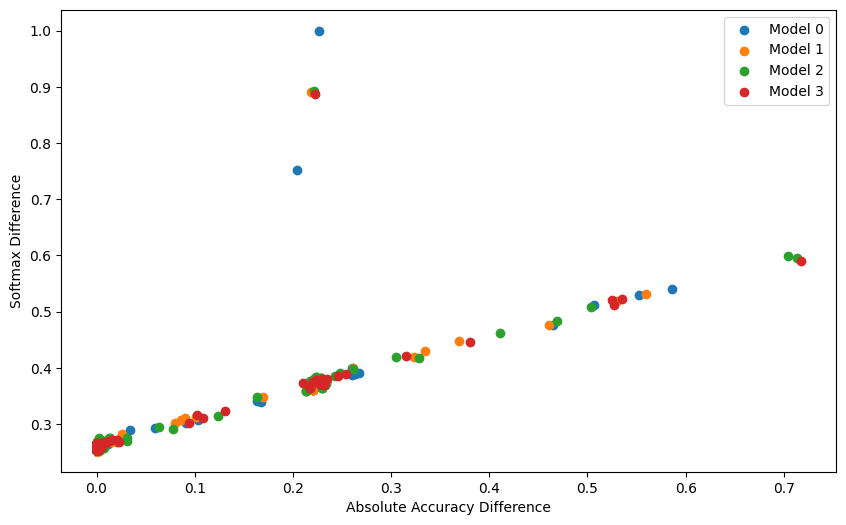

In [5]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for modelvariant in df_master['folder_name'].unique():
    subset = df_master[df_master['folder_name'] == modelvariant]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=modelvariant)
#plt.scatter(df_master['abs_acc_diff'], df_master['softmax_difference'])
plt.xlabel('Absolute Accuracy Difference')
plt.ylabel('Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()

In [6]:
df_master

,activation_fn,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,0,conv1,weight,0,0.97625,0.97625,0.00000,0.262279,2.236513e-02,NaN,0,Model 0,0.00000,-1.650429,0.000000
1,relu,0,conv1,weight,1,0.97625,0.71625,-0.26000,0.388053,3.805229e+36,NaN,0,Model 0,0.26000,36.580381,0.670011
2,relu,0,conv1,weight,3,0.97625,0.97625,0.00000,0.262237,1.118256e-02,NaN,1,Model 0,0.00000,-1.951459,0.000000
3,relu,0,conv1,weight,6,0.97625,0.97625,0.00000,0.262037,1.677385e-01,NaN,0,Model 0,0.00000,-0.775367,0.000000
4,relu,0,conv1,weight,10,0.97625,0.97625,0.00000,0.262204,1.953125e-03,NaN,1,Model 0,0.00000,-2.709270,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347,relu,-1,fc1,bias,3,0.97375,0.97375,0.00000,0.263226,3.650101e-02,NaN,1,Model 3,0.00000,-1.437695,0.000000
2348,relu,-1,fc1,bias,6,0.97375,0.97750,0.00375,0.263429,5.475152e-01,NaN,0,Model 3,0.00375,-0.261604,0.014235
2349,relu,-1,fc1,bias,10,0.97375,0.97375,0.00000,0.263208,7.812500e-03,NaN,0,Model 3,0.00000,-2.107210,0.000000
2350,relu,-1,fc1,bias,15,0.97375,0.97375,0.00000,0.263211,2.441406e-04,NaN,1,Model 3,0.00000,-3.612360,0.000000


In [7]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_2['diff_per_softmax'] = df_summary_2['abs_acc_diff'] / df_summary_2['softmax_difference']
df_summary_2['metrics_rms'] = np.sqrt((df_summary_2['abs_acc_diff']**2 + df_summary_2['softmax_difference']**2)/2)
df_summary_2

,location_layer,location_module,abs_acc_diff,softmax_difference,metrics_rms
0,conv1,bias,0.004828,0.265122,0.187500
1,conv1,weight,0.006996,0.269570,0.190679
2,conv2,bias,0.002098,0.262172,0.185389
3,conv2,weight,0.005765,0.264047,0.186754
4,fc1,bias,0.032561,0.277261,0.197400
5,fc1,weight,0.037194,0.279154,0.199136


In [8]:
latex_text = create_neat_latex(df_summary_2, 
                               comment="Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{lllll}
\toprule
location\_layer & location\_module & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
conv1 & bias & \B{0}{0.0048} & \B{0}{0.2651} & \B{0}{0.1875} \\
conv1 & weight & \B{0}{0.0070} & \B{0}{0.2696} & \B{0}{0.1907} \\
conv2 & bias & \B{1}{0.0021} & \B{1}{0.2622} & \B{1}{0.1854} \\
conv2 & weight & \B{0}{0.0058} & \B{0}{0.2640} & \B{0}{0.1868} \\
fc1 & bias & \B{0}{0.0326} & \B{0}{0.2773} & \B{0}{0.1974} \\
fc1 & weight & \B{0}{0.0372} & \B{0}{0.2792} & \B{0}{0.1991} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0048}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2651}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1875}' has dtype 

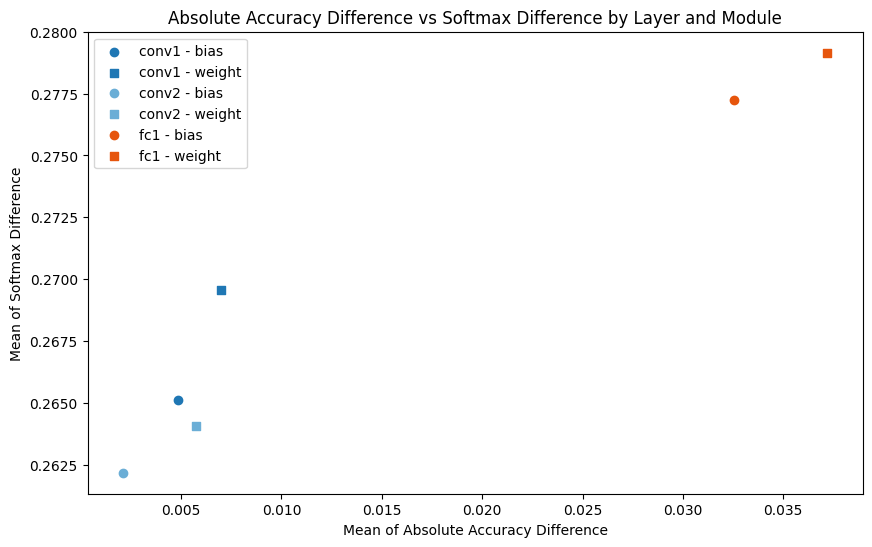

In [9]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
module_markers = {
    'bias': 'o',
    'weight': 's',
}
colors = {
    'conv1': '#1f77b4',
    'conv2': '#6baed6',
    'fc1':'#e6550d',
}

for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}', marker=module_markers[module], color=colors[layer])
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [10]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_3['diff_per_softmax'] = df_summary_3['abs_acc_diff'] / df_summary_3['softmax_difference']
df_summary_3['metrics_rms'] = np.sqrt((df_summary_3['abs_acc_diff']**2 + df_summary_3['softmax_difference']**2)/2)
df_summary_3

,activation_fn,abs_acc_diff,softmax_difference,metrics_rms
0,actRWG,0.007779,0.265099,0.187534
1,actWG,0.017775,0.271577,0.192445
2,relu,0.023423,0.283511,0.201155
3,relu6,0.011369,0.265334,0.187791
4,sigmoid,0.013624,0.259768,0.183936
5,sin,0.014066,0.270160,0.191290
6,tanh,0.016313,0.271431,0.192277


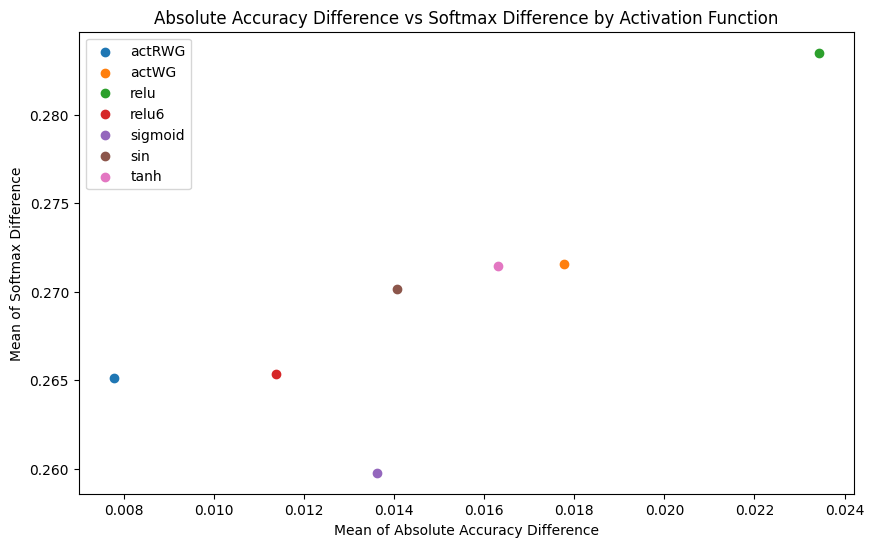

In [11]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [12]:
latex_text = create_neat_latex(df_summary_3, 
                               comment="Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{llll}
\toprule
activation\_fn & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
actRWG & \B{1}{0.0078} & \B{0}{0.2651} & \B{0}{0.1875} \\
actWG & \B{0}{0.0178} & \B{0}{0.2716} & \B{0}{0.1924} \\
relu & \B{0}{0.0234} & \B{0}{0.2835} & \B{0}{0.2012} \\
relu6 & \B{0}{0.0114} & \B{0}{0.2653} & \B{0}{0.1878} \\
sigmoid & \B{0}{0.0136} & \B{1}{0.2598} & \B{1}{0.1839} \\
sin & \B{0}{0.0141} & \B{0}{0.2702} & \B{0}{0.1913} \\
tanh & \B{0}{0.0163} & \B{0}{0.2714} & \B{0}{0.1923} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{1}{0.0078}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2651}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1875}' has dtype 

In [13]:
df_summary = df_master.groupby(['activation_fn',
                   #'prior',
                   #'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#folder_name_map = {
#    'results_shipsnet_deterministic_00_SEU': 'Model 0',
#    'results_shipsnet_deterministic_01_SEU': 'Model 1',
#    'results_shipsnet_deterministic_02_SEU': 'Model 2',
#    'results_shipsnet_deterministic_03_SEU': 'Model 3',
#}
#df_summary['folder_name'] = df_summary['folder_name'].map(folder_name_map)
df_summary

,activation_fn,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,-1,conv1,bias,Model 0,0.000357,0.262764
1,actRWG,-1,conv1,bias,Model 1,0.000536,0.263987
2,actRWG,-1,conv1,bias,Model 2,0.004107,0.263019
3,actRWG,-1,conv1,bias,Model 3,0.000893,0.258556
4,actRWG,-1,conv1,weight,Model 0,0.000179,0.262913
...,...,...,...,...,...,...,...
331,tanh,0,fc1,bias,Model 3,0.031964,0.277373
332,tanh,0,fc1,weight,Model 0,0.083750,0.302593
333,tanh,0,fc1,weight,Model 1,0.052679,0.289189
334,tanh,0,fc1,weight,Model 2,0.071964,0.300691


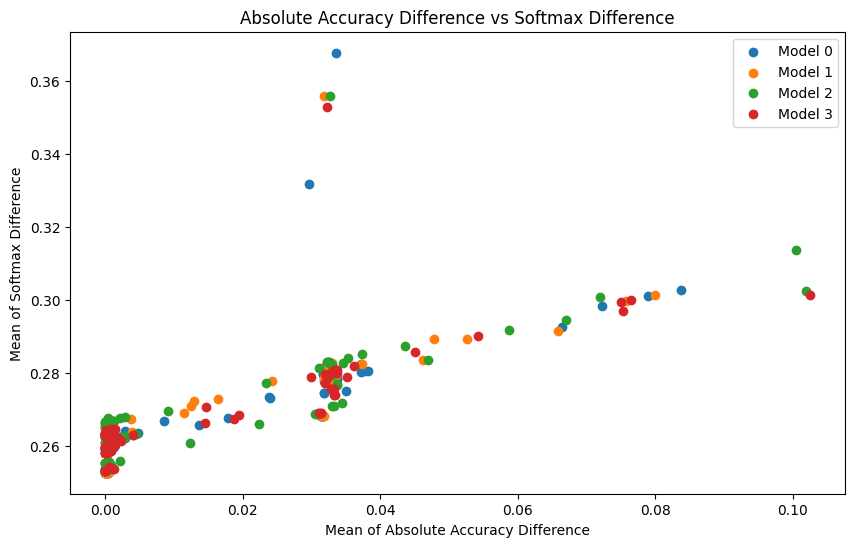

In [14]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [15]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_6['diff_per_softmax'] = df_summary_6['abs_acc_diff'] / df_summary_6['softmax_difference']
df_summary_6['metrics_rms'] = np.sqrt((df_summary_6['abs_acc_diff']**2 + df_summary_6['softmax_difference']**2)/2)
# map the values of folder_name to a more readable format
#folder_name_map = {
#    'results_shipsnet_deterministic_00_SEU': 'Model 0',
#    'results_shipsnet_deterministic_01_SEU': 'Model 1',
#    'results_shipsnet_deterministic_02_SEU': 'Model 2',
#    'results_shipsnet_deterministic_03_SEU': 'Model 3',
#}
#df_summary_6['folder_name'] = df_summary_6['folder_name'].map(folder_name_map)
df_summary_6

,folder_name,abs_acc_diff,softmax_difference,metrics_rms
0,Model 0,0.014532,0.269426,0.190790
1,Model 1,0.014158,0.269877,0.191094
2,Model 2,0.015721,0.270202,0.191385
3,Model 3,0.015217,0.268711,0.190312


In [16]:
latex_text = create_neat_latex(df_summary_6, 
                               comment="Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by activation function for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{llll}
\toprule
folder\_name & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
Model 0 & \B{0}{0.0145} & \B{0}{0.2694} & \B{0}{0.1908} \\
\midrule
Model 1 & \B{1}{0.0142} & \B{0}{0.2699} & \B{0}{0.1911} \\
\midrule
Model 2 & \B{0}{0.0157} & \B{0}{0.2702} & \B{0}{0.1914} \\
\midrule
Model 3 & \B{0}{0.0152} & \B{1}{0.2687} & \B{1}{0.1903} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0145}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2694}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1908}' has dtype 

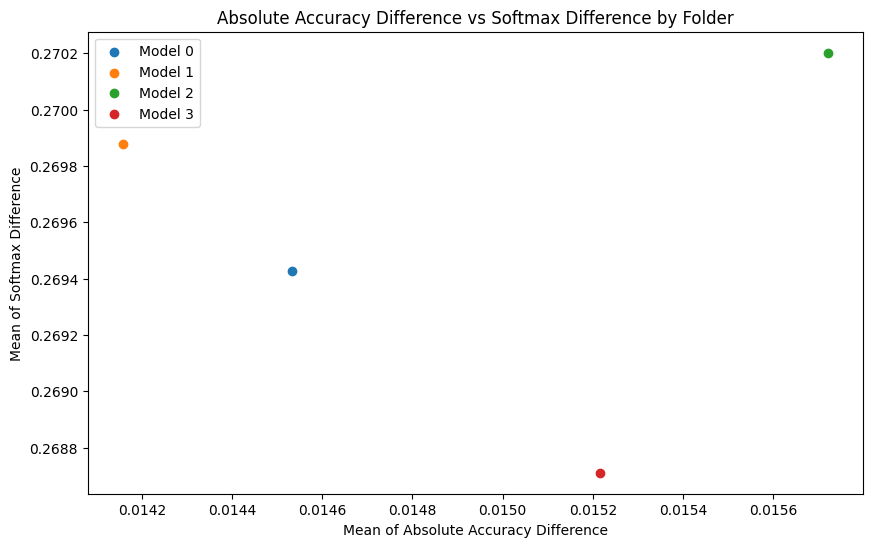

In [17]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()

In [18]:
df_summary_8 = df_master.groupby(['original_bit_condition'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_8['diff_per_softmax'] = df_summary_8['abs_acc_diff'] / df_summary_8['softmax_difference']
df_summary_8['metrics_rms'] = np.sqrt((df_summary_8['abs_acc_diff']**2 + df_summary_8['softmax_difference']**2)/2)
df_summary_8

,original_bit_condition,abs_acc_diff,softmax_difference,metrics_rms
0,0,0.027467,0.276691,0.196612
1,1,0.000190,0.261192,0.184691


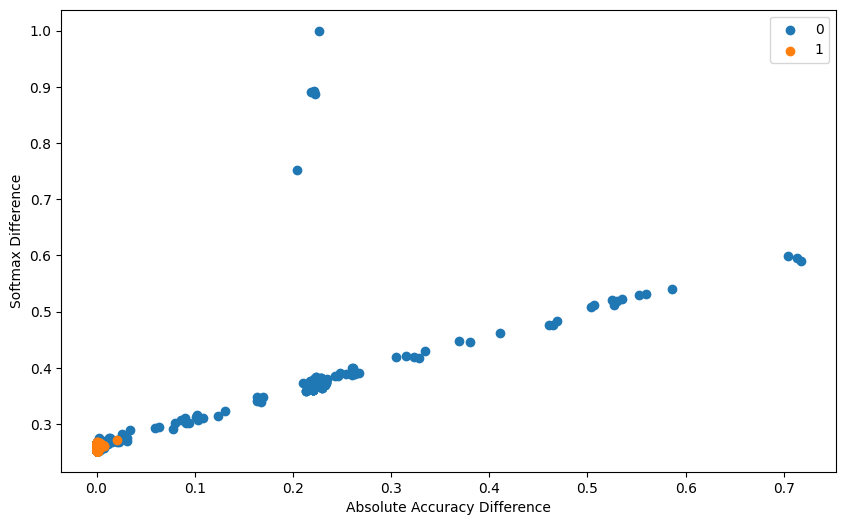

In [29]:
plt.figure(figsize=(10, 6))
for originalbit in df_master['original_bit_condition'].unique():
    subset = df_master[df_master['original_bit_condition'] == originalbit]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=originalbit)
#plt.scatter(df_master['abs_acc_diff'], df_master['softmax_difference'])
plt.xlabel('Absolute Accuracy Difference')
plt.ylabel('Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()

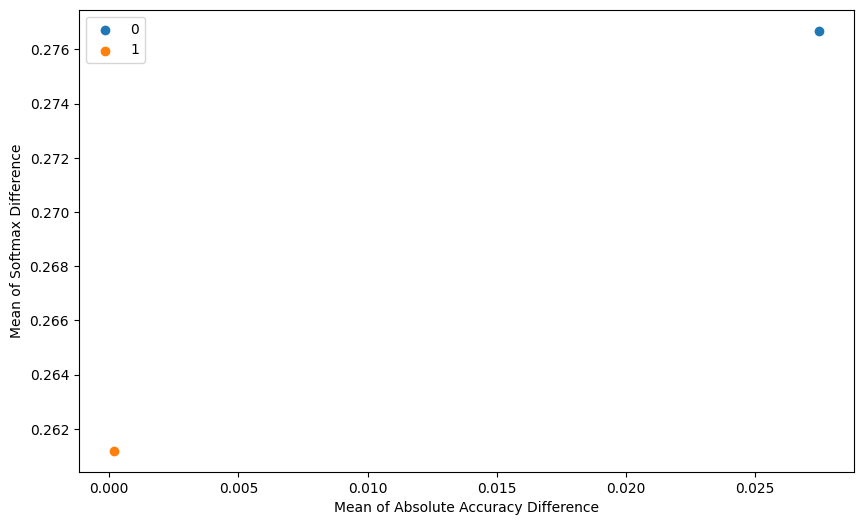

In [19]:
plt.figure(figsize=(10, 6))
for orbitloc in df_summary_8['original_bit_condition'].unique():
    subset = df_summary_8[(df_summary_8['original_bit_condition']==orbitloc)]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{orbitloc}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference by Original Bit Condition')
plt.legend()
plt.show()

In [20]:
latex_text = create_neat_latex(df_summary_8, 
                               comment="Summary of absolute accuracy difference and softmax difference by original bit for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by original bit for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{rlll}
\toprule
original\_bit\_condition & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
0 & \B{0}{0.0275} & \B{0}{0.2767} & \B{0}{0.1966} \\
1 & \B{1}{0.0002} & \B{1}{0.2612} & \B{1}{0.1847} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0275}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2767}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1966}' has dtype 

In [21]:
df_master

,activation_fn,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,0,conv1,weight,0,0.97625,0.97625,0.00000,0.262279,2.236513e-02,NaN,0,Model 0,0.00000,-1.650429,0.000000
1,relu,0,conv1,weight,1,0.97625,0.71625,-0.26000,0.388053,3.805229e+36,NaN,0,Model 0,0.26000,36.580381,0.670011
2,relu,0,conv1,weight,3,0.97625,0.97625,0.00000,0.262237,1.118256e-02,NaN,1,Model 0,0.00000,-1.951459,0.000000
3,relu,0,conv1,weight,6,0.97625,0.97625,0.00000,0.262037,1.677385e-01,NaN,0,Model 0,0.00000,-0.775367,0.000000
4,relu,0,conv1,weight,10,0.97625,0.97625,0.00000,0.262204,1.953125e-03,NaN,1,Model 0,0.00000,-2.709270,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347,relu,-1,fc1,bias,3,0.97375,0.97375,0.00000,0.263226,3.650101e-02,NaN,1,Model 3,0.00000,-1.437695,0.000000
2348,relu,-1,fc1,bias,6,0.97375,0.97750,0.00375,0.263429,5.475152e-01,NaN,0,Model 3,0.00375,-0.261604,0.014235
2349,relu,-1,fc1,bias,10,0.97375,0.97375,0.00000,0.263208,7.812500e-03,NaN,0,Model 3,0.00000,-2.107210,0.000000
2350,relu,-1,fc1,bias,15,0.97375,0.97375,0.00000,0.263211,2.441406e-04,NaN,1,Model 3,0.00000,-3.612360,0.000000


In [22]:
df_summary_9 = df_master.groupby(['bit_index'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_9['diff_per_softmax'] = df_summary_9['abs_acc_diff'] / df_summary_9['softmax_difference']
df_summary_9['metrics_rms'] = np.sqrt((df_summary_9['abs_acc_diff']**2 + df_summary_9['softmax_difference']**2)/2)
df_summary_9

,bit_index,abs_acc_diff,softmax_difference,metrics_rms
0,0,0.000465,0.261319,0.184781
1,1,0.102295,0.319264,0.237059
2,3,0.000223,0.261192,0.184690
3,6,0.001295,0.261692,0.185046
4,10,0.000063,0.261140,0.184654
5,15,0.000007,0.261136,0.184651
6,21,0.000000,0.261136,0.184651


In [23]:
latex_text = create_neat_latex(df_summary_9, 
                               comment="Summary of absolute accuracy difference and softmax difference by bit location for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by bit location for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{rlll}
\toprule
bit\_index & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
0 & \B{0}{0.0005} & \B{0}{0.2613} & \B{0}{0.1848} \\
1 & \B{0}{0.1023} & \B{0}{0.3193} & \B{0}{0.2371} \\
3 & \B{0}{0.0002} & \B{0}{0.2612} & \B{0}{0.1847} \\
6 & \B{0}{0.0013} & \B{0}{0.2617} & \B{0}{0.1850} \\
10 & \B{0}{0.0001} & \B{0}{0.2611} & \B{0}{0.1847} \\
15 & \B{0}{0.0000} & \B{1}{0.2611} & \B{1}{0.1847} \\
21 & \B{1}{0.0000} & \B{1}{0.2611} & \B{1}{0.1847} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0005}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2613}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1848}' has dtype 

In [24]:
df_master

,activation_fn,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,0,conv1,weight,0,0.97625,0.97625,0.00000,0.262279,2.236513e-02,NaN,0,Model 0,0.00000,-1.650429,0.000000
1,relu,0,conv1,weight,1,0.97625,0.71625,-0.26000,0.388053,3.805229e+36,NaN,0,Model 0,0.26000,36.580381,0.670011
2,relu,0,conv1,weight,3,0.97625,0.97625,0.00000,0.262237,1.118256e-02,NaN,1,Model 0,0.00000,-1.951459,0.000000
3,relu,0,conv1,weight,6,0.97625,0.97625,0.00000,0.262037,1.677385e-01,NaN,0,Model 0,0.00000,-0.775367,0.000000
4,relu,0,conv1,weight,10,0.97625,0.97625,0.00000,0.262204,1.953125e-03,NaN,1,Model 0,0.00000,-2.709270,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347,relu,-1,fc1,bias,3,0.97375,0.97375,0.00000,0.263226,3.650101e-02,NaN,1,Model 3,0.00000,-1.437695,0.000000
2348,relu,-1,fc1,bias,6,0.97375,0.97750,0.00375,0.263429,5.475152e-01,NaN,0,Model 3,0.00375,-0.261604,0.014235
2349,relu,-1,fc1,bias,10,0.97375,0.97375,0.00000,0.263208,7.812500e-03,NaN,0,Model 3,0.00000,-2.107210,0.000000
2350,relu,-1,fc1,bias,15,0.97375,0.97375,0.00000,0.263211,2.441406e-04,NaN,1,Model 3,0.00000,-3.612360,0.000000


In [25]:
df_summary_10 = df_master.groupby(['location_index'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
# map the values of folder_name to a more readable format
folder_name_map = {
    0: 'First neuron',
    -1: 'Last neuron',
}
df_summary_10['location_index'] = df_summary_10['location_index'].map(folder_name_map)
#df_summary_10['diff_per_softmax'] = df_summary_10['abs_acc_diff'] / df_summary_10['softmax_difference']
df_summary_10['metrics_rms'] = np.sqrt((df_summary_10['abs_acc_diff']**2 + df_summary_10['softmax_difference']**2)/2)

In [26]:
latex_text = create_neat_latex(df_summary_10, 
                               comment="Summary of absolute accuracy difference and softmax difference by neuron location for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by neuron location for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{llll}
\toprule
location\_index & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
Last neuron & \B{0}{0.0152} & \B{0}{0.2702} & \B{0}{0.1914} \\
First neuron & \B{1}{0.0146} & \B{1}{0.2689} & \B{1}{0.1904} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0152}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2702}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1914}' has dtype 

In [27]:
df_summary_11 = df_master.groupby(['location_index','folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
# map the values of folder_name to a more readable format
folder_name_map = {
    0: 'First neuron',
    -1: 'Last neuron',
}
df_summary_11['location_index'] = df_summary_11['location_index'].map(folder_name_map)
#df_summary_11['diff_per_softmax'] = df_summary_11['abs_acc_diff'] / df_summary_11['softmax_difference']
df_summary_11['metrics_rms'] = np.sqrt((df_summary_11['abs_acc_diff']**2 + df_summary_11['softmax_difference']**2)/2)
df_summary_11 = df_summary_11.sort_values(by=['folder_name','location_index'])
df_summary_11

,location_index,folder_name,abs_acc_diff,softmax_difference,metrics_rms
4,First neuron,Model 0,0.015013,0.270073,0.191265
0,Last neuron,Model 0,0.014052,0.268780,0.190316
5,First neuron,Model 1,0.013516,0.268668,0.190217
1,Last neuron,Model 1,0.014800,0.271086,0.191973
6,First neuron,Model 2,0.014426,0.268701,0.190274
2,Last neuron,Model 2,0.017015,0.271702,0.192499
7,First neuron,Model 3,0.015642,0.268002,0.189829
3,Last neuron,Model 3,0.014792,0.269421,0.190796


In [28]:
latex_text = create_neat_latex(df_summary_11, 
                               comment="Summary of absolute accuracy difference and softmax difference by neuron location and model variant for Deterministic CNN",
                               highlight_cols = ['abs_acc_diff', 'softmax_difference', 'metrics_rms'],
                               ascending=True,
                               highlight_method="col")
print(latex_text)

%Summary of absolute accuracy difference and softmax difference by neuron location and model variant for Deterministic CNN
\begin{table}[h]
\centering
\begin{tabular}{lllll}
\toprule
location\_index & folder\_name & abs\_acc\_diff & softmax\_difference & metrics\_rms \\
\midrule
First neuron & Model 0 & \B{0}{0.0150} & \B{0}{0.2701} & \B{0}{0.1913} \\
Last neuron & Model 0 & \B{0}{0.0141} & \B{0}{0.2688} & \B{0}{0.1903} \\
First neuron & Model 1 & \B{1}{0.0135} & \B{0}{0.2687} & \B{0}{0.1902} \\
Last neuron & Model 1 & \B{0}{0.0148} & \B{0}{0.2711} & \B{0}{0.1920} \\
First neuron & Model 2 & \B{0}{0.0144} & \B{0}{0.2687} & \B{0}{0.1903} \\
Last neuron & Model 2 & \B{0}{0.0170} & \B{0}{0.2717} & \B{0}{0.1925} \\
First neuron & Model 3 & \B{0}{0.0156} & \B{1}{0.2680} & \B{1}{0.1898} \\
Last neuron & Model 3 & \B{0}{0.0148} & \B{0}{0.2694} & \B{0}{0.1908} \\
\bottomrule
\end{tabular}
\caption{...}
\label{table:...}
\end{table}


C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.0150}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.2701}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.iat[i] = r"\B{%d}{%0.4f}" % (1 if np.isclose(v, target) else 0, v)
C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_18400\331566506.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\B{0}{0.1913}' has dtype 